# Copy-Paste Augmentation Visualization Demo

Notebook này sinh ra các cặp hình ảnh So Sánh Trực Quan (Gốc và Đã Dán) để bạn Copy trực tiếp cho vào SLIDE BÁO CÁO.

In [3]:
import sys
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Thêm folder gốc vào sys.path để gọi module
sys.path.append(os.path.abspath(".."))

from dataset.pascal_voc import VOCSegDataset, VOC_COLORMAP
from dataset.augmentations import CopyPasteAugmentation

## Khởi tạo Dataset và Bộ Công Cụ Copy-Paste

In [4]:
# Khởi tạo bộ dữ liệu PASCAL VOC (Không áp dụng Transforms cơ bản để nhìn ảnh gốc cho rõ nét)
dataset = VOCSegDataset(root="../data", year="2012", image_set="train", download=True)

# Ép tỷ lệ paste_prob=1.0 để luôn luôn thực hiện hành vi dán đè (thay vì xác suất hên xui như mặc định)
copy_paste_aug = CopyPasteAugmentation(
    dataset=dataset, paste_prob=1.0, max_paste_objects=2
)

100%|██████████| 2.00G/2.00G [05:58<00:00, 5.58MB/s] 


## Hàm hỗ trợ trực quan hóa

In [5]:
def decode_segmap(mask):
    """Giải mã mảng Mask 1D thành ảnh RGB theo màu Palette chuẩn của PASCAL VOC."""
    mask_np = np.array(mask)
    rgb = np.zeros((mask_np.shape[0], mask_np.shape[1], 3), dtype=np.uint8)

    for cls_idx, color in enumerate(VOC_COLORMAP):
        rgb[mask_np == cls_idx] = color

    # Viền phông và vùng cần bỏ qua (Tọa độ 255) được bôi màu xám/trắng nhạt
    rgb[mask_np == 255] = [200, 200, 200]
    return rgb


def show_demo(target_idx):
    # 1. Lấy ảnh gốc đóng vai trò làm Vùng Mục Tiêu (Target)
    orig_image, orig_mask = dataset.get_raw(target_idx)

    # Phân thân nhái thêm một bản sao
    img_copy, mask_copy = orig_image.copy(), orig_mask.copy()

    # 2. Dùng máy biến hóa CopyPaste đúp vào bản sao.
    # Máy sẽ tự động qua nhà hàng xóm (Random src_idx) bắt một con động vật bất kì rồi chèn vào bức ảnh này.
    pasted_image, pasted_mask = copy_paste_aug(img_copy, mask_copy)

    # --- Plots ---
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    axs[0, 0].imshow(orig_image)
    axs[0, 0].set_title("Target Ảnh Gốc", fontsize=16)
    axs[0, 0].axis("off")

    axs[0, 1].imshow(decode_segmap(orig_mask))
    axs[0, 1].set_title("Target Mask Gốc (Đáp án)", fontsize=16)
    axs[0, 1].axis("off")

    axs[1, 0].imshow(pasted_image)
    axs[1, 0].set_title(
        "Ảnh được dán thêm Vật thể (Copy-Paste)",
        fontsize=16,
        color="red",
        fontweight="bold",
    )
    axs[1, 0].axis("off")

    axs[1, 1].imshow(decode_segmap(pasted_mask))
    axs[1, 1].set_title(
        "Mask chứa vật thể được dán", fontsize=16, color="red", fontweight="bold"
    )
    axs[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

## Tiến hành Generator sinh ảnh ngẫu nhiên
Bạn nhấn Run chạy lại liên tục ô code dưới đây. Mô hình sẽ gắp các con vật/đồ nội thất ngẫu nhiên ném thẳng lên không gian ảnh mới. 
**MẸO ĂN ĐIỂM GIẢNG VIÊN:** Chạy đến khi nào thấy tấm ảnh hài hước, đẹp mắt (VD con bò đang gặm cỏ tự dưng bị cắt dán đè lên bãi biển / oto đậu lơ lửng giữa trời) thì **"Right Click -> Copy Image"** nhét cái bụp vào Slide. Sự phi lý đấy chính gốc là Extreme Regularization.

Đang dùng bức ảnh Target ID: 803 làm bối cảnh nền...


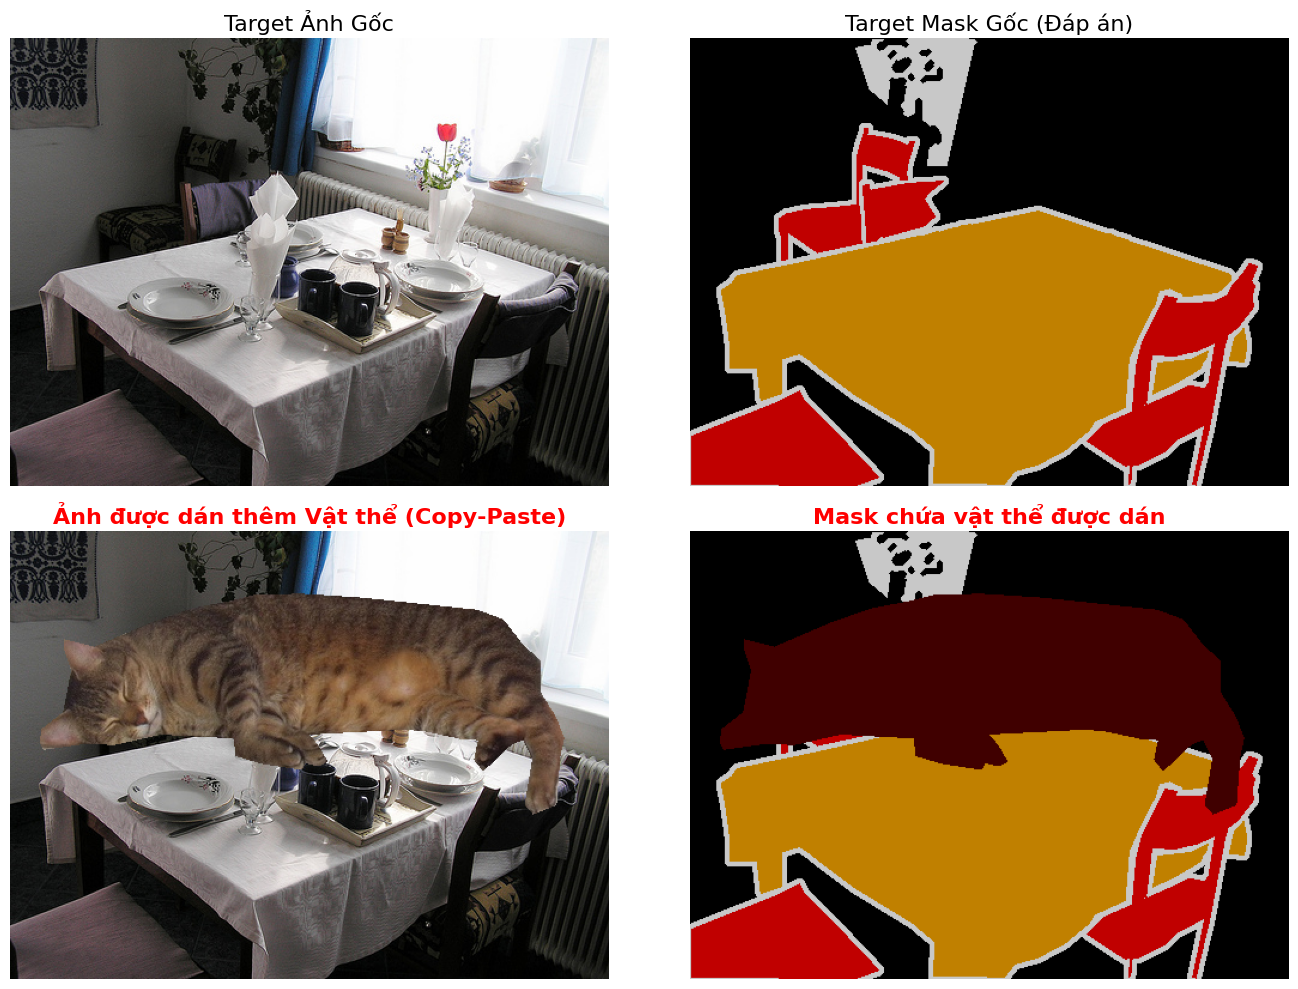

In [9]:
random_target_idx = random.randint(0, len(dataset) - 1)
print(f"Đang dùng bức ảnh Target ID: {random_target_idx} làm bối cảnh nền...")
show_demo(random_target_idx)